In [2]:
import pandas as pd
import os
import re

# 1. Cấu hình đường dẫn
path = os.getcwd()
input_file = os.path.join(path, "job_kaggle.csv")
output_file = os.path.join(path, "job_kaggle_transformed.csv")

# 2. Định nghĩa bảng ánh xạ (Mapping) giữa tên cũ và tên mới
column_mapping = {
    'JobID': 'job_id',
    'Job Title': 'job_title',
    'Name Company': 'company_name',
    'Salary': 'salary_full', 
    'Job Address': 'job_address',
    'Submission Deadline': 'deadline',
    'Years of Experience': 'job_experience_required',
    'Job Type': 'employment_type',
    'Career Level': 'job_function',
    'Industry': 'industries',
    'Job Description': 'job_description',
    'Job Requirements': 'job_requirement',
    'Benefits': 'benefits'
}

# Thứ tự các cột đầu ra theo đúng yêu cầu của bạn
final_columns = [
    'job_id', 'job_title', 'company_name', 'salary_min', 'salary_max', 
    'job_address', 'deadline', 'job_experience_required', 'employment_type', 
    'job_function', 'industries', 'benefits','job_description', 'job_requirement', 
    
]

def split_salary(row):
    salary_full = str(row['salary_full']).replace('Lương', '').replace(':', '').strip()
    
    s_min, s_max = "", ""
    
    if '-' in salary_full:
        parts = salary_full.split('-')
        if len(parts) == 2:
            s_min = parts[0].strip()
            s_max = parts[1].strip()
            
            # Sử dụng Regex để tìm đơn vị (ví dụ: Tr, VND, USD) ở cuối s_max
            unit_match = re.search(r'([A-Za-z ]+)$', s_max)
            unit = unit_match.group(1).strip() if unit_match else ""
            
            # Nếu s_min chưa có đơn vị, ta ghép đơn vị từ s_max vào cho đồng bộ
            if not any(u in s_min for u in ['Tr', 'VND', '$', 'USD']):
                s_min = f"{s_min} {unit}".strip()
    else:
        # Xử lý trường hợp "Thỏa thuận" hoặc chỉ có 1 con số
        s_min = salary_full
        if salary_full.lower() == 'thỏa thuận':
            s_max = salary_full
            
    return pd.Series([s_min, s_max])

try:
    # 3. Đọc file cũ
    df = pd.read_csv(input_file, encoding='utf-8-sig') 
    
    # 4. Đổi tên các cột theo mapping
    df = df.rename(columns=column_mapping)

    # 5. Áp dụng hàm tách lương thông minh
    if 'salary_full' in df.columns:
        df[['salary_min', 'salary_max']] = df.apply(split_salary, axis=1)
    else:
        df['salary_min'] = ""
        df['salary_max'] = ""

    # 6. Đảm bảo tất cả các cột yêu cầu đều tồn tại (kể cả cột mới như job_listed)
    for col in final_columns:
        if col not in df.columns:
            df[col] = ""

    # Sắp xếp lại thứ tự cột
    df_final = df[final_columns]

    # 7. Lưu file mới
    df_final.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"--- Chuyển đổi thành công! ---")
    print(f"File lưu tại: {output_file}")
    print(f"Số lượng bản ghi: {len(df_final)}")

except Exception as e:
    print(f"Lỗi thực thi: {e}")

--- Chuyển đổi thành công! ---
File lưu tại: f:\OneDrive\TAI_LIEU_HK8\PBL\job-recommendation-system\data\raw\job\job_kaggle_transformed.csv
Số lượng bản ghi: 14634


In [3]:
import pandas as pd
import os

# 1. Cấu hình đường dẫn
path = os.getcwd()
file_name = "job_kaggle_transformed.csv" # Hoặc tên file bạn đang dùng
input_file = os.path.join(path, file_name)

try:
    # 2. Đọc file
    df = pd.read_csv(input_file, encoding='utf-8-sig')

    # 3. Chuyển đổi cột deadline sang kiểu dữ liệu datetime
    # dayfirst=True vì định dạng trong ảnh của bạn là Ngày/Tháng/Năm
    df['deadline'] = pd.to_datetime(df['deadline'], dayfirst=True, errors='coerce')

    # 4. Cộng thêm 3 năm và 4 tháng dùng DateOffset
    # Cách này sẽ tự động xử lý logic lịch (ví dụ: cộng tháng vào cuối năm sẽ nhảy sang năm mới)
    df['deadline'] = df['deadline'] + pd.DateOffset(years=3, months=4)

    # 5. Định dạng lại về kiểu Ngày/Tháng/Năm (dd/mm/yyyy) để lưu vào CSV
    df['deadline'] = df['deadline'].dt.strftime('%d/%m/%Y')

    # 6. Lưu file
    df.to_csv(input_file, index=False, encoding='utf-8-sig')
    print("--- Đã cộng thêm 3 năm 4 tháng vào cột deadline thành công! ---")

except Exception as e:
    print(f"Lỗi: {e}")

--- Đã cộng thêm 3 năm 4 tháng vào cột deadline thành công! ---


In [4]:
import pandas as pd
import os

# 1. Cấu hình đường dẫn
path = os.getcwd()
file_name = "job_kaggle_transformed.csv"
input_file = os.path.join(path, file_name)

try:
    # 2. Đọc file
    df = pd.read_csv(input_file, encoding='utf-8-sig')

    # 3. Chuyển sang định dạng ngày tháng (ép kiểu dd/mm/yyyy)
    df['deadline'] = pd.to_datetime(df['deadline'], dayfirst=True, errors='coerce')

    # 4. TRỪ LẠI 1 THÁNG (Sử dụng months=-1)
    # Hoặc bạn có thể sửa thẳng thành pd.DateOffset(years=3, months=3)
    df['deadline'] = df['deadline'] - pd.DateOffset(months=1)

    # 5. Định dạng lại dd/mm/yyyy trước khi lưu
    df['deadline'] = df['deadline'].dt.strftime('%d/%m/%Y')

    # 6. Lưu file đè lên file cũ
    df.to_csv(input_file, index=False, encoding='utf-8-sig')
    print("--- Đã lùi lại 1 tháng thành công! ---")

except Exception as e:
    print(f"Lỗi: {e}")

--- Đã lùi lại 1 tháng thành công! ---


In [2]:
import os
import pandas as pd

folder = "raw/job"
all_dfs = []

# Lặp qua tất cả các file trong thư mục
for filename in os.listdir(folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder, filename)
        # Đọc file và thêm vào danh sách
        df = pd.read_csv(file_path)
        all_dfs.append(df)

# Nối tất cả các dataframe lại với nhau
combined_df = pd.concat(all_dfs, ignore_index=True)

# Lưu thành file mới để tiền xử lý
combined_df.to_csv("combined_data.csv", index=False, encoding='utf-8-sig')

print(f"Đã gộp xong! Tổng số dòng: {len(combined_df)}")

Đã gộp xong! Tổng số dòng: 46924


In [2]:
import re
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from textblob import Word
from nltk.util import ngrams
import re
from wordcloud import WordCloud, STOPWORDS
from nltk.tokenize import word_tokenize

In [3]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Tải dữ liệu stopwords (từ dừng)
nltk.download('stopwords')

# Đọc file đã gộp
df = pd.read_csv("combined_data.csv")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\voquy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
import re
import pandas as pd

def clean_text_keep_dot(text):
    if pd.isna(text): return ""
    text = str(text).lower() # 01. Chuyển về chữ thường
    
    # 02. Xóa dấu chấm câu NHƯNG giữ lại dấu chấm (.)
    # Regex này xóa các ký tự đặc biệt trừ chữ cái, số, khoảng trắng và dấu chấm
    text = re.sub(r'[^\w\s\.]', '', text) 
    
    # 04. Chuẩn hóa văn bản (xóa khoảng trắng thừa)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Áp dụng cho các cột văn bản
df['job_description'] = df['job_description'].apply(clean_text_keep_dot)
df['job_requirement'] = df['job_requirement'].apply(clean_text_keep_dot)

In [6]:
# Giả sử bạn dùng nltk cho tiếng Anh
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def process_tokens(text):
    # 06. Tách từ bằng dấu cách
    words = text.split()
    # 03. Xóa từ dừng (chỉ xóa nếu không phải dấu chấm)
    filtered = [w for w in words if w in ['.'] or w not in stop_words]
    return " ".join(filtered)

df['job_description'] = df['job_description'].apply(process_tokens)

In [ ]:
#remove watermarks
import re

def remove_watermarks(text):
    if not text:
        return text
    
    # Xóa các dòng chứa thuvienphapluat và biến thể
    text = re.sub(r'[^\n]*(?:thuvienphapluat|thư[_\s]*viện[_\s]*pháp)[^\n]*', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'[^\n]*(?:ihuvietphapluat|ihuviệtphapluat)[^\n]*', ' ', text, flags=re.IGNORECASE)
    
    # Xóa số điện thoại watermark (84 + số)
    text = re.sub(r'[^\n]*\b84\b[^\n]*\b\d{2,4}\b[^\n]*\b\d{4}\b[^\n]*\b\d{4}\b[^\n]*', ' ', text, flags=re.IGNORECASE)
    
    # Xóa từ watermark: awsoft, sofi, jel, tek, ặc, iju
    watermark_words = ['awsoft', 'sofi', r'\bjel\b', r'\btek\b', r'\bặc\b', r'\biju\b']
    for word in watermark_words:
        text = re.sub(r'[^\n]*' + word + r'[^\n]*', ' ', text, flags=re.IGNORECASE)
    
    # Xóa số watermark: 3930, 3279, 327X
    text = re.sub(r'\b3930\b|\b3279\b|\b327\d\b', ' ', text, flags=re.IGNORECASE)
    
    # Xóa URL, email
    text = re.sub(r'(?:www\.|http://|https://)[^\s]+', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', text, flags=re.IGNORECASE)
    
    # Xóa unicode escape
    text = re.sub(r'\\u[0-9A-Fa-f]+', ' ', text)
    
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

for i in range(len(tweet_sample)):
    tweet_sample[i] = remove_watermarks(tweet_sample[i])
    if (i+1) % 50 == 0:
        print(f"   ✅ {i+1}/{len(tweet_sample)} file")



   ✅ 50/426 file


In [ ]:
import re

for i in range(len(tweet_sample)):
    tweet_sample[i] = re.sub(r'trang \d+', '', tweet_sample[i])
    
    tweet_sample[i] = re.sub(r'\s+', ' ', tweet_sample[i]).strip()

print(tweet_sample[0])

chính phủ cộng hoà xã hội chủ nghĩa việt nam độc lập tự do hạnh phúc số 78 2020 nđ cp hà nội ngày 06 tháng 7 năm 2020 nghị định về sĩ quan dự bị quân đội nhân dân việt nam căn cứ luật tổ chức chính phủ ngày 19 tháng 6 năm 2015 căn cứ luật sĩ quan quân đội nhân dân việt nam ngày 21 tháng 2 năm 1999 luật sửa đổi bổ sung một số điều của luật sĩ quan quân đội nhân dân việt nam ngày 03 tháng 6 năm 2008 luật sửa đổi bổ sung một số điều số điều của luật sĩ quan quân đội nhân dân việt nam ngày 27 tháng 04 ï năm 2014 căn cứ luật lực lượng dự bị động viên ngày 26 tháng 12 năm 2019 theo đề nghị của bộ trưởng bộ quốc phòng chính phủ ban hành nghị định về sĩ quan dự bị quân đội nhân dân việt nam chương i quy định chung điều 1 phạm vi điều chỉnh nghị định này quy định việc tuyển chọn đào tạo sĩ quan dự bị đăng ký quản lý huấn luyện sắp xếp bổ nhiệm miễn nhiệm chức vụ giáng chức cách chức phong thăng giáng tước quân hàm giải ngạch sĩ quan dự bị gọi sĩ quan dự bị vào phục vụ tại ngũ điều 2 đối tượng á

In [ ]:
#3. remove stop words

import re

vi_stopwords = {
    "và", "là", "của", "có", "cho", "được", "một", "những", "các", "đã", "đang", 
    "trong", "khi", "này", "đó", "tại", "với", "từ", "đến", "theo", "vì", "nên", 
    "người", "sự", "các", "như", "nếu", "thì", "mà", "về", "để", "lại", "ra"
}

for i in range(len(tweet_sample)):
    text = tweet_sample[i]

    words = text.split()
    
    filtered_words = [w for w in words if w not in vi_stopwords]
    
    tweet_sample[i] = ' '.join(filtered_words)

print(tweet_sample[0])

chính phủ cộng hoà xã hội chủ nghĩa việt nam độc lập tự do hạnh phúc số 78 2020 nđ cp hà nội ngày 06 tháng 7 năm 2020 nghị định sĩ quan dự bị quân đội nhân dân việt nam căn cứ luật tổ chức chính phủ ngày 19 tháng 6 năm 2015 căn cứ luật sĩ quan quân đội nhân dân việt nam ngày 21 tháng 2 năm 1999 luật sửa đổi bổ sung số điều luật sĩ quan quân đội nhân dân việt nam ngày 03 tháng 6 năm 2008 luật sửa đổi bổ sung số điều số điều luật sĩ quan quân đội nhân dân việt nam ngày 27 tháng 04 ï năm 2014 căn cứ luật lực lượng dự bị động viên ngày 26 tháng 12 năm 2019 đề nghị bộ trưởng bộ quốc phòng chính phủ ban hành nghị định sĩ quan dự bị quân đội nhân dân việt nam chương i quy định chung điều 1 phạm vi điều chỉnh nghị định quy định việc tuyển chọn đào tạo sĩ quan dự bị đăng ký quản lý huấn luyện sắp xếp bổ nhiệm miễn nhiệm chức vụ giáng chức cách chức phong thăng giáng tước quân hàm giải ngạch sĩ quan dự bị gọi sĩ quan dự bị vào phục vụ ngũ điều 2 đối tượng áp dụng 1 sĩ quan dự bị hạ sĩ quan dự bị

In [ ]:
#4. normalization

import re

abbreviation_dict = {
    "nđ": "nghị định",
    "cp": "chính phủ",
    "qđ": "quyết định",
    "nq": "nghị quyết",
    "ttg": "thủ tướng", 
    "qđ-ttg": "quyết định thủ tướng chính phủ",
    "tp": "thành phố",
    "vn": "việt nam",
    "ttr": "tờ trình", 
    "kh": "kế hoạch",  
    "ubnd": "ủy ban nhân dân",
    "hđnd": "hội đồng nhân dân",
    "qyđ": "quy định"
}

sorted_abbrs = sorted(abbreviation_dict.keys(), key=len, reverse=True)

pattern = re.compile(r'\b(' + '|'.join(map(re.escape, sorted_abbrs)) + r')\b')

def expand_abbreviations(text):
    def replace(match):
        return abbreviation_dict[match.group(0)]
    
    return pattern.sub(replace, text)

for i in range(len(tweet_sample)):
    text = tweet_sample[i]
    
    text = expand_abbreviations(text)
    
    tweet_sample[i] = text

print(tweet_sample[0]) 

chính phủ cộng hoà xã hội chủ nghĩa việt nam độc lập tự do hạnh phúc số 78 2020 nghị định chính phủ hà nội ngày 06 tháng 7 năm 2020 nghị định sĩ quan dự bị quân đội nhân dân việt nam căn cứ luật tổ chức chính phủ ngày 19 tháng 6 năm 2015 căn cứ luật sĩ quan quân đội nhân dân việt nam ngày 21 tháng 2 năm 1999 luật sửa đổi bổ sung số điều luật sĩ quan quân đội nhân dân việt nam ngày 03 tháng 6 năm 2008 luật sửa đổi bổ sung số điều số điều luật sĩ quan quân đội nhân dân việt nam ngày 27 tháng 04 ï năm 2014 căn cứ luật lực lượng dự bị động viên ngày 26 tháng 12 năm 2019 đề nghị bộ trưởng bộ quốc phòng chính phủ ban hành nghị định sĩ quan dự bị quân đội nhân dân việt nam chương i quy định chung điều 1 phạm vi điều chỉnh nghị định quy định việc tuyển chọn đào tạo sĩ quan dự bị đăng ký quản lý huấn luyện sắp xếp bổ nhiệm miễn nhiệm chức vụ giáng chức cách chức phong thăng giáng tước quân hàm giải ngạch sĩ quan dự bị gọi sĩ quan dự bị vào phục vụ ngũ điều 2 đối tượng áp dụng 1 sĩ quan dự bị hạ

In [ ]:
# #5. correction

# import torch
# from transformers import pipeline
# import os

# os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# device = 0 if torch.cuda.is_available() else -1
# print(f"✅ Thiết bị đang dùng: {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")

# corrector = pipeline(
#     "text2text-generation", 
#     model="bmd1905/vietnamese-correction", 
#     device=device
# )

# def smart_chunk_text(text, max_words=80): 
#     words = text.split()
#     chunks = []
#     current_chunk = []
    
#     for word in words:
#         current_chunk.append(word)
#         if len(current_chunk) >= max_words:
#             chunks.append(' '.join(current_chunk))
#             current_chunk = []
            
#     if current_chunk:
#         chunks.append(' '.join(current_chunk))
#     return chunks

# print("🚀 Đang bắt đầu sửa lỗi...")

# for i in range(len(tweet_sample)): 
#     original_text = tweet_sample[i]
    
#     text_chunks = smart_chunk_text(original_text)
    
#     if not text_chunks: continue

#     corrected_chunks = []
    
#     try:
#         results = corrector(
#             text_chunks, 
#             batch_size=4, 
#             max_length=512 
#         )
        
#         for res in results:
#             corrected_chunks.append(res['generated_text'])
            
#         corrected_text = ' '.join(corrected_chunks)
#         corrected_text = corrected_text.lower() 
#         tweet_sample[i] = corrected_text
        
#         print(f"✅ Đã sửa xong file {i+1}")
        
                   
#     except Exception as e:
#         print(f"❌ Vẫn lỗi ở file {i}: {e}")



In [ ]:
!pip install py-vncorenlp



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#6. segmentation

try:
    import underthesea
except ImportError:
    !pip install underthesea
    import underthesea

from underthesea import word_tokenize
import tqdm 
def segment_text_underthesea(text):
    if not text: return ""
    try:
        return word_tokenize(text, format="text")
    except:
        return text

for i in range(len(tweet_sample)):
    original_text = tweet_sample[i]
    
    tweet_sample[i] = segment_text_underthesea(original_text)
    
    if (i+1) % 500 == 0:
        print(f"✅ Đã xử lý xong {i+1} file...")


if len(tweet_sample) > 0:
    print(tweet_sample[0])

c:\Users\voquy\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


chính_phủ cộng_hòa xã_hội_chủ_nghĩa_việt_nam độc_lập tự_do hạnh_phúc số 78 2020 nghị_định chính_phủ hà_nội ngày 06 tháng 7 năm 2020 nghị_định sĩ_quan dự_bị quân_đội nhân_dân việt_nam căn_cứ luật tổ_chức chính_phủ ngày 19 tháng 6 năm 2015 căn_cứ luật_sĩ_quan quân_đội nhân_dân việt_nam ngày 21 tháng 2 năm 1999 luật sửa_đổi bổ_sung số điều_luật sĩ_quan quân_đội nhân_dân việt_nam ngày 03 tháng 6 năm 2008 luật sửa_đổi bổ_sung số điều_số điều_luật sĩ_quan quân_đội nhân_dân việt_nam ngày 27 tháng 04 ï năm 2014 căn_cứ luật lực_lượng dự_bị động_viên ngày 26 tháng 12 năm 2019 đề_nghị bộ_trưởng bộ quốc_phòng chính_phủ ban_hành nghị_định sĩ_quan dự_bị quân_đội nhân_dân việt_nam chương i quy_định chung_điều 1 phạm_vi điều_chỉnh nghị_định quy_định việc tuyển_chọn đào_tạo sĩ_quan dự_bị đăng_ký quản_lý huấn_luyện sắp_xếp bổ_nhiệm miễn_nhiệm chức_vụ giáng_chức cách_chức phong_thăng giáng_tước quân_hàm giải_ngạch sĩ_quan dự_bị gọi sĩ_quan dự_bị vào phục_vụ ngũ điều 2 đối_tượng áp_dụng 1 sĩ_quan dự_bị hạ

In [ ]:
#7. Lưu kết quả cuối cùng vào từng file riêng

import os
from tqdm import tqdm

# Tạo thư mục output
output_folder = "data_token/"
os.makedirs(output_folder, exist_ok=True)

print(f"📁 Bắt đầu lưu {len(tweet_sample)} file vào {output_folder}...")

# Lưu từng file với tên tương ứng
for i, processed_text in enumerate(tqdm(tweet_sample, desc="💾 Đang lưu file")):
    # Lấy tên file gốc
    original_filename = os.path.basename(txt_files[i])
    
    # Tạo tên file mới (thay _AI_Corrected bằng _PROCESSED hoặc giữ nguyên)
    new_filename = original_filename.replace("_AI_Corrected.txt", "_PROCESSED.txt")
    
    # Đường dẫn file output
    output_path = os.path.join(output_folder, new_filename)
    
    # Lưu file
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(processed_text)

print(f"✅ Hoàn thành! Đã lưu {len(tweet_sample)} file vào {output_folder}")
print(f"📊 Dung lượng trung bình: {sum([len(t) for t in tweet_sample]) / len(tweet_sample):.0f} ký tự/file")

📁 Bắt đầu lưu 426 file vào data_token/...


💾 Đang lưu file: 100%|██████████| 426/426 [00:00<00:00, 2008.46it/s]

✅ Hoàn thành! Đã lưu 426 file vào data_token/
📊 Dung lượng trung bình: 34951 ký tự/file


In [ ]:
#8. [OPTIONAL] Load lại dữ liệu đã xử lý (để dùng lần sau)

import os
import glob

processed_folder = "processed_data_final/"

# Kiểm tra xem folder có tồn tại không
if os.path.exists(processed_folder):
    processed_files = glob.glob(os.path.join(processed_folder, "*.txt"))
    
    if len(processed_files) > 0:
        print(f"📂 Tìm thấy {len(processed_files)} file đã xử lý trong {processed_folder}")
        
        # Load tất cả file đã xử lý
        tweet_sample_loaded = []
        for file_path in sorted(processed_files):
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                tweet_sample_loaded.append(content)
        
        print(f"✅ Đã load {len(tweet_sample_loaded)} file đã xử lý")
        print(f"📄 Ví dụ file đầu tiên ({len(tweet_sample_loaded[0])} ký tự):")
        print(tweet_sample_loaded[0][:200] + "...")
        
        # Gán lại vào tweet_sample nếu muốn dùng
        # tweet_sample = tweet_sample_loaded
    else:
        print("⚠️ Không tìm thấy file nào trong folder")
else:
    print(f"⚠️ Folder {processed_folder} chưa tồn tại. Chạy cell #7 để tạo.")

⚠️ Folder processed_data_final/ chưa tồn tại. Chạy cell #7 để tạo.


In [ ]:
!pip install matplotlib seaborn wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


------------------------------
1. Tổng số văn bản (Documents): 426
2. Tổng số từ (Total Words): 2114745
3. Số từ vựng duy nhất (Vocabulary Size): 61606
4. Độ dài trung bình văn bản: 4964.19 từ
------------------------------


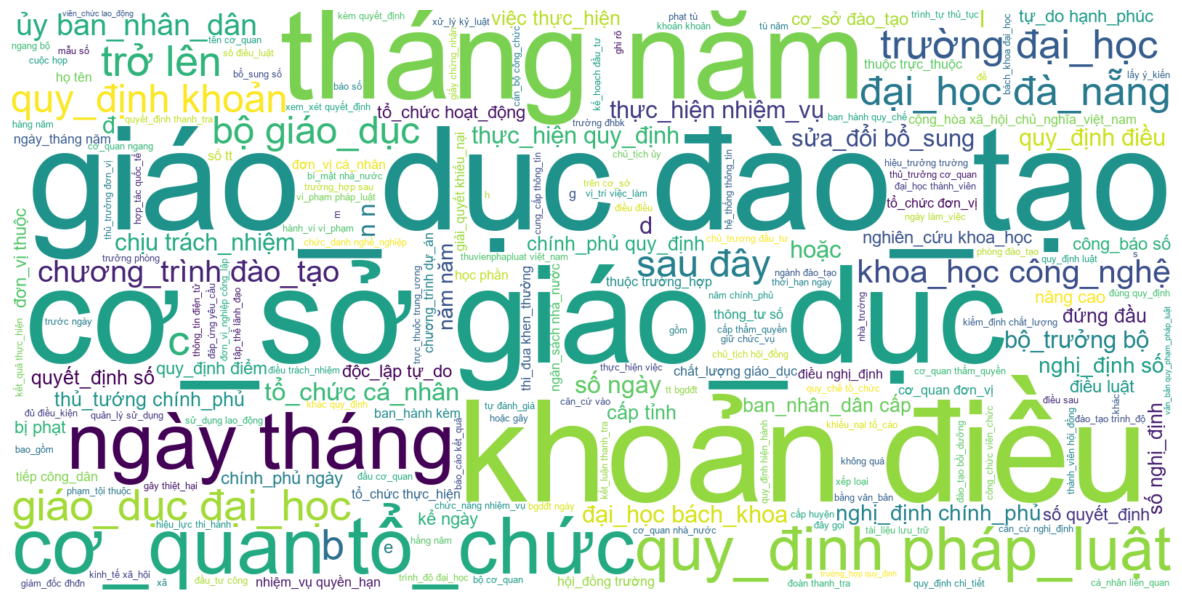

C:\Users\voquy\AppData\Local\Temp\ipykernel_4828\44221557.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


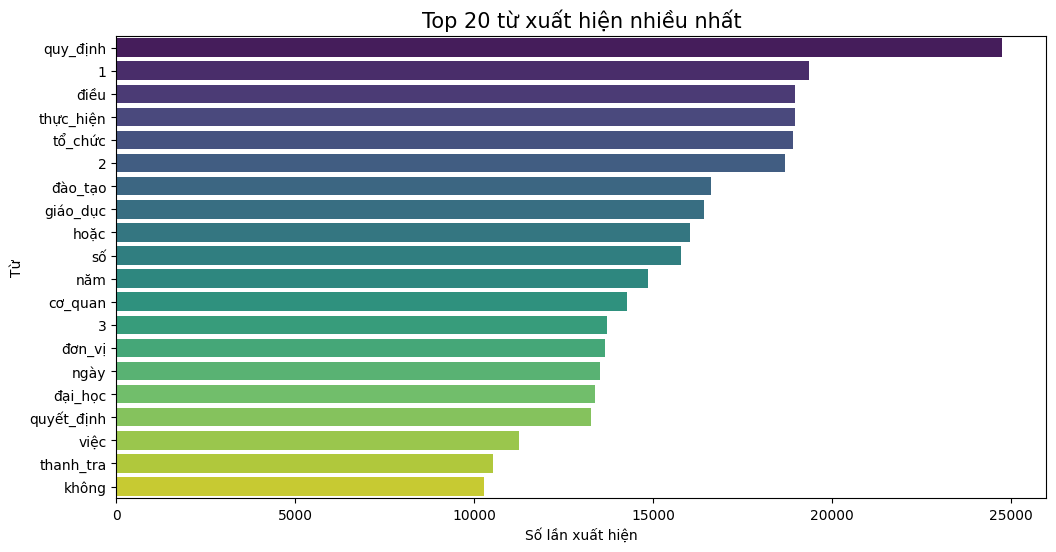

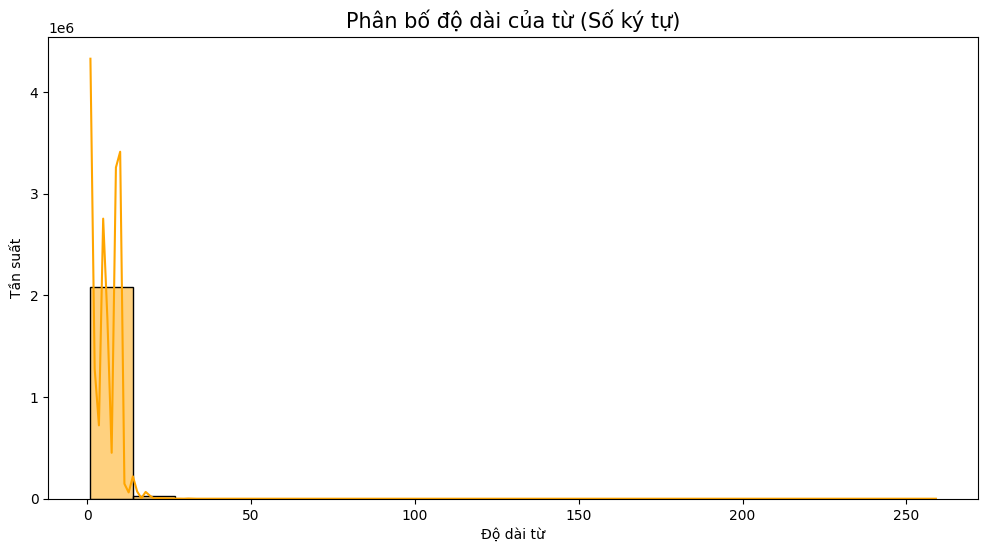

In [ ]:
#9. analysis 

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)

all_words = []
doc_lengths = []

for text in tweet_sample:
    words = text.split() 
    all_words.extend(words)
    doc_lengths.append(len(words))

print("-" * 30)
print(f"1. Tổng số văn bản (Documents): {len(tweet_sample)}")
print(f"2. Tổng số từ (Total Words): {len(all_words)}")
print(f"3. Số từ vựng duy nhất (Vocabulary Size): {len(set(all_words))}")
print(f"4. Độ dài trung bình văn bản: {np.mean(doc_lengths):.2f} từ")
print("-" * 30)


text_for_cloud = " ".join(tweet_sample)


font_path = "C:/Windows/Fonts/arial.ttf" 

try:
    wordcloud = WordCloud(
        width=1600, height=800,
        background_color='white',
        font_path=font_path, # Quan trọng để hiển thị tiếng Việt
        colormap='viridis',
        max_words=200
    ).generate(text_for_cloud)

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"⚠️ Lỗi vẽ WordCloud (có thể do font): {e}")


word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

words = [w[0] for w in most_common_words]
counts = [w[1] for w in most_common_words]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 từ xuất hiện nhiều nhất', fontsize=15)
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Từ')
plt.show()


word_lengths = [len(w) for w in all_words]

plt.figure(figsize=(12, 6))
sns.histplot(word_lengths, bins=20, kde=True, color='orange')
plt.title('Phân bố độ dài của từ (Số ký tự)', fontsize=15)
plt.xlabel('Độ dài từ')
plt.ylabel('Tần suất')
plt.show()

